In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## Part 1
Load the data and split it in training,validation and testing sets

In [11]:
df = pd.read_csv("./data/fer2013.csv")

print( df['Usage'].value_counts() )

Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


In [12]:
# We use for training and validation the "Training" and "PublicTest"
trai_df = df[df['Usage']== 'Training'].copy()
vali_df = df[df['Usage'] == 'PublicTest'].copy()
test_df = df[df['Usage'] == 'PrivateTest'].copy() 

# Storing train and test data frames
trai_df.to_csv("./data/fer2013_train.csv", encoding='utf-8', index=False)
vali_df.to_csv("./data/fer2013_validation.csv", encoding='utf-8', index=False)
test_df.to_csv("./data/fer2013_test.csv", encoding='utf-8', index=False)

## Part 2
statistics and labelling

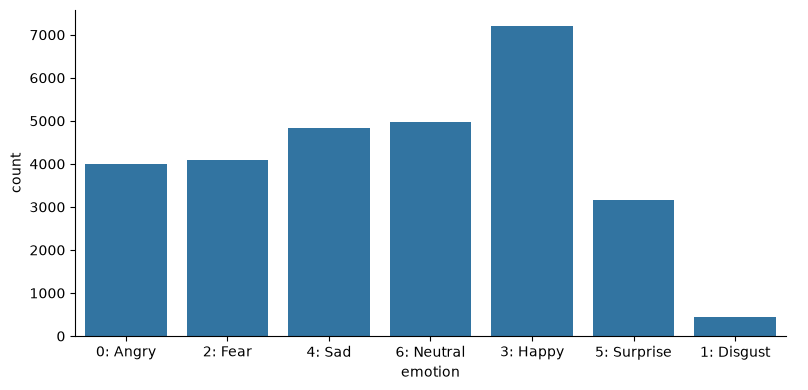

In [13]:
emotionDict = {
    0:'0: Angry',
    1:'1: Disgust',
    2:'2: Fear',
    3:'3: Happy',
    4:'4: Sad',
    5:'5: Surprise',
    6:'6: Neutral'
}


sns.catplot(data=trai_df.replace({'emotion': emotionDict}), kind='count', x='emotion', height=4, aspect=2)

plt.show()

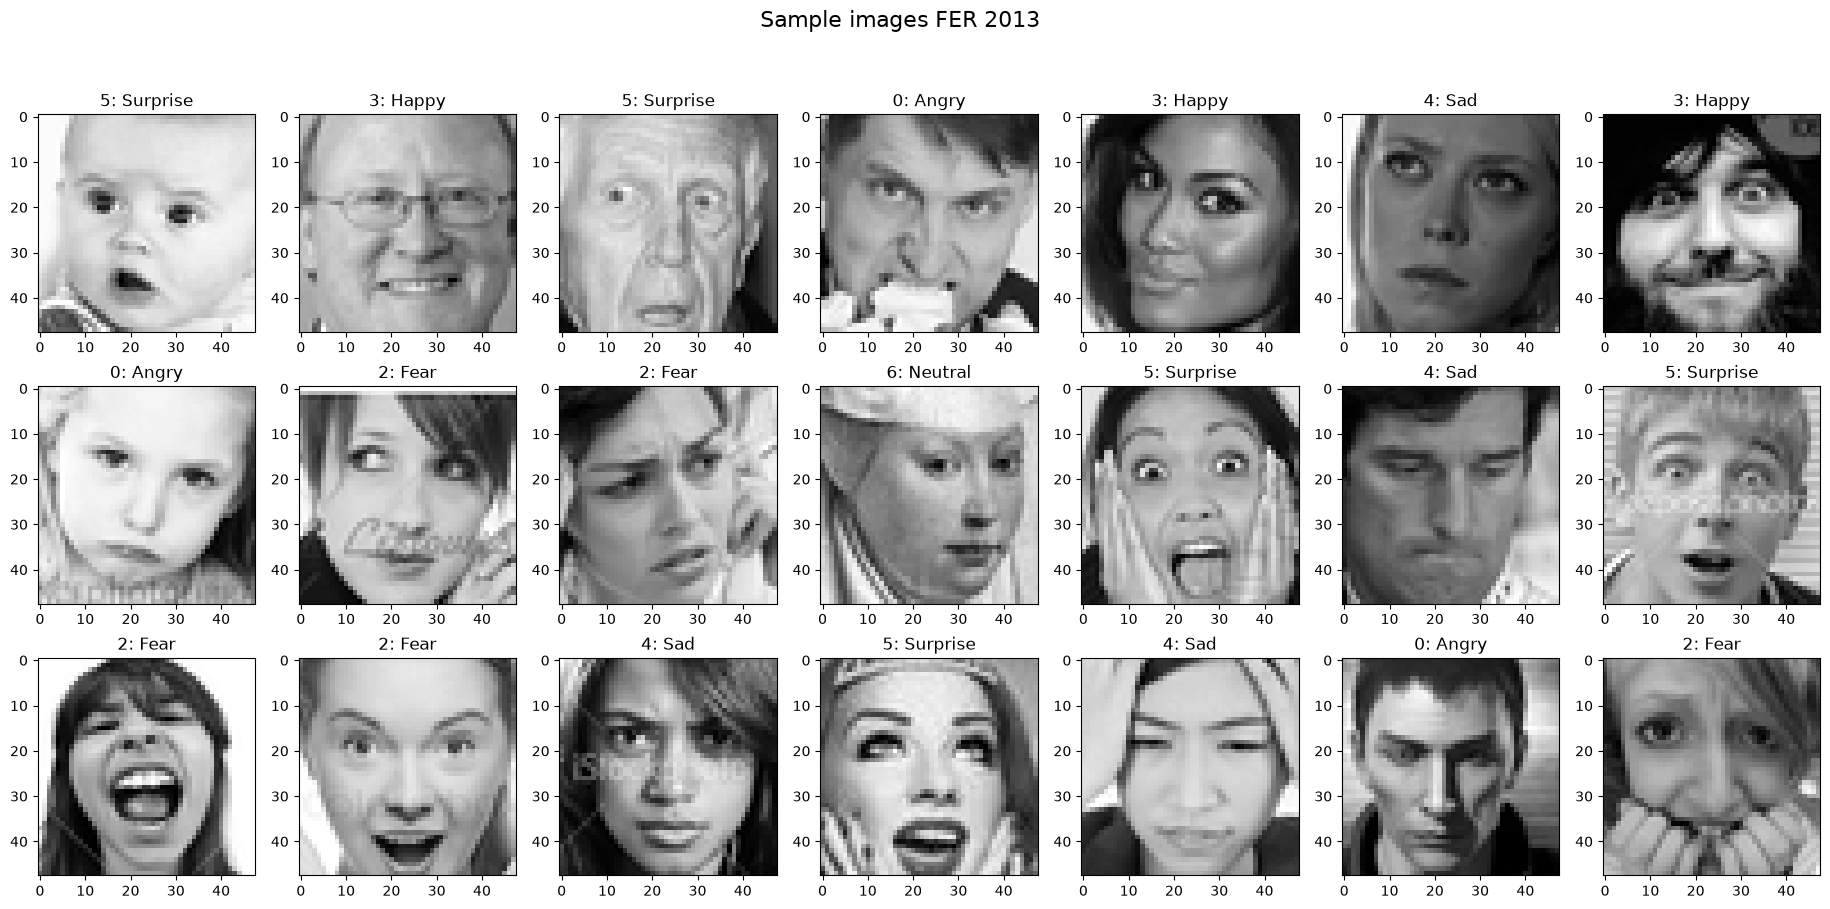

In [14]:
# Now making some plots
random_rows = df.sample(n=21, random_state=43)
imgs = [np.fromstring(pixels, sep=' ').reshape(48, 48) for pixels in random_rows['pixels']]
lbl =  random_rows['emotion'].values

fig, axes = plt.subplots(nrows=3, ncols=7, figsize=(23, 10))
fig.suptitle('Sample images FER 2013', fontsize=16)

# Loop through each subplot and customize
for i in range(7):
    for j in range(3):
        ax = axes[j, i]
        ax.imshow(imgs[j*7+i], cmap="gray") 
        ax.set_title('%s'%(emotionDict[lbl[j*7+i]]))
        #ax.grid(True)
plt.show()


Compyting the class weights for the training test

In [15]:
csv_file = './data/fer2013_train.csv'
model_file = "./models/rf_fer_model_landmarks.pkl"

## Loading the Data

In [16]:
from sklearn.utils.class_weight import compute_class_weight

trai_df = pd.read_csv(csv_file)

# Computing class weights for unbalanced dataset
labelsTrain = trai_df['emotion'].values
cw = compute_class_weight(
    class_weight="balanced", classes=np.unique(labelsTrain), y=labelsTrain)
#class_weights = {0:cw[0],1:cw[1],2:cw[2], 3:cw[3], 4:cw[4], 5:cw[5], 6:cw[6]}

## Feature extraction pipeline

In [ ]:
import dlib 

# Importing dlib's landmark detector
# Dlib landmarks from: 
#   https://github.com/davisking/dlib-models/blob/master/shape_predictor_68_face_landmarks.dat.bz2
landmDet = dlib.shape_predictor("faceAndLandmarkModels/shape_predictor_68_face_landmarks.dat")


def extractLandmarksFER(images):
    face_rects = dlib.rectangle(left=1, top=1, right=47, bottom=47)
    x1 = face_rects.left() 
    y1 = face_rects.top() 
    x2 = face_rects.right() 
    y2 = face_rects.bottom()

    landm = []
    for img in images:
        la = landmDet(img.astype(np.uint8), face_rects)

        # This works better if the standard scaler is not usec
        la2 = np.asarray( np.matrix([
            [
                (p.x-0.5*(x2-x1))/(x2-x1), (p.y-0.5*(y2-y1))/(y2-y1)
            ] for p in la.parts()])).astype(np.float32)
        la2 -= np.mean(la2, axis=0, keepdims=True)
        la2 /= np.max(np.abs(la2), axis=0, keepdims=True)

        landm.append(la2.flatten())
    feats = np.stack(landm)
    return(feats)

# Loading the images
images = np.array(
        [np.fromstring(pixels, sep=' ').reshape(48, 48) for pixels in trai_df['pixels']])
feats = extractLandmarksFER(images)

images = None

## Evaluating the results

In [25]:
from sklearn.ensemble import RandomForestClassifier
import joblib


rf = RandomForestClassifier(
    n_estimators=300,       # Number of trees
    max_depth=11,           # Allow trees to grow fully
    max_features='sqrt',   # Use sqrt(features) for splitting
    random_state=42,
    n_jobs=-1,             # Use all available CPU cores 
    #class_weight= "balanced", #class_weights,
    criterion="entropy",
)


rf.fit(feats, trai_df['emotion'].values)

joblib.dump(rf, model_file)
print(f"Model saved to {model_file}")

Model saved to ./models/rf_fer_model_landmarks.pkl


Perform to validation test

Accuracy: 0.48
Balanced accuracy: 0.41
Macro F1: 0.41


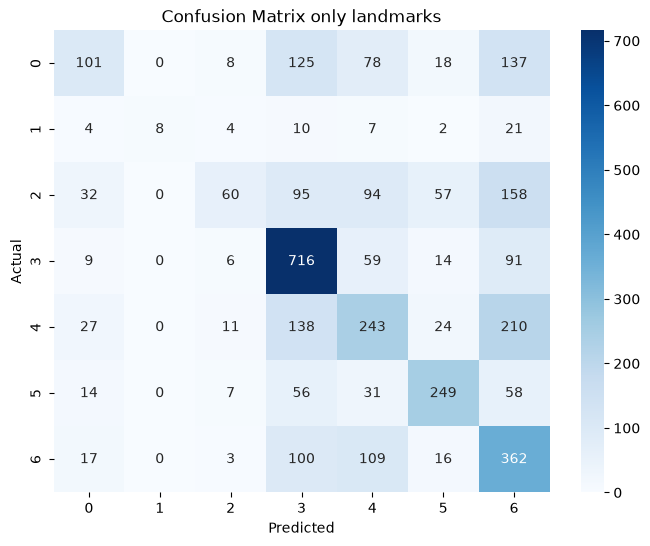

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score, f1_score

def preprocessingFer(dataFrame):
    # Convert pixel strings to 48x48 images
    images = np.array(
        [np.fromstring(pixels, sep=' ').reshape(48, 48) for pixels in dataFrame['pixels']])
    X =  extractLandmarksFER(images)
    y = dataFrame['emotion'].values
    return([X,y])


# Predict and evaluate
valid = pd.read_csv('./data/fer2013_validation.csv')
X_valid, y_valid = preprocessingFer(valid)

y_pred = rf.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
conf_matrix = confusion_matrix(y_valid, y_pred)

baccuracy = balanced_accuracy_score(y_valid, y_pred)
macro_f1 = f1_score(y_valid, y_pred, average='macro')


# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"Balanced accuracy: {baccuracy:.2f}")
print(f"Macro F1: {macro_f1:.2f}")


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix only landmarks")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
